## Feautres to consider:

- Length
- Topology complexity (big difference between protons & kaons)
- Log likelihood (for dE/dx)

Ideas?
- 



The evidence pool:

- Have discriminating features, calculated directly from the original proton and kaon clusters
- Correlation matrix with latent dimensions
- Traverse each dimension and see what changes in the images
- Check linear predictions
- Check non-linear predictions
- Calculate features on reconstructed images and compare with original
- Show kaons sit in a different quadrant than protons on the calo, topo axes.
- Include muons.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import entropy, skew, kurtosis
from scipy.signal import peak_widths, find_peaks
from scipy.ndimage import uniform_filter1d
from skimage.measure import label, regionprops

In [ ]:
col = pd.read_pickle('/Volumes/easystore/proton-kaon/clusters/col.pkl')
ind = pd.read_pickle('/Volumes/easystore/proton-kaon/clusters/ind.pkl')

In [ ]:
col.columns

In [ ]:
def plot_feature(col, feature, bins=50, xlabel=None):
    
    protons = col[col['particle_type'] == 'proton'][feature].dropna()
    kaons   = col[col['particle_type'] == 'kaon'][feature].dropna()

    combined_min = min(protons.min(), kaons.min())
    combined_max = max(protons.max(), kaons.max())
    bin_edges = np.linspace(combined_min, combined_max, bins + 1)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(protons, bins=bin_edges, alpha=0.6, label='Proton', density=True)
    ax.hist(kaons,   bins=bin_edges, alpha=0.6, label='Kaon',   density=True)
    ax.set_xlabel(xlabel or feature)
    ax.set_ylabel("Density")
    ax.set_title(feature)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def total_adc(image):
    return np.log(np.sum(image))

total_adc = [total_adc(a) for a in col.image_intensity]
col['total_adc'] = total_adc 

In [ ]:
def mean_adc(image):
    return np.mean(image)

mean_adc = [mean_adc(a) for a in col.image_intensity]
col['mean_adc'] = mean_adc 

In [ ]:
def median_adc(image):
    return np.median(image[image > 0])

median_adc = [median_adc(a) for a in col.image_intensity]
col['median_adc'] = median_adc 

In [ ]:
def max_adc(image):
    return np.max(image)

max_adc = [max_adc(a) for a in col.image_intensity]
col['max_adc'] = max_adc 

In [ ]:
def std_adc(image):
    return np.std(image[image > 0])

std_adc = [std_adc(a) for a in col.image_intensity]
col['std_adc'] = std_adc 

In [ ]:
def n_pixels(image):
    return np.log(np.sum(image > 0))

n_pixels = [n_pixels(a) for a in col.image_intensity]
col['n_pixels'] = n_pixels

In [ ]:
def adc_entropy(image, n_bins=50):
    pixels = image[image > 0].ravel()
    if len(pixels) < 2:
        return np.nan
    counts, _ = np.histogram(pixels, bins=n_bins)
    n_occupied = (counts > 0).sum()
    if n_occupied < 2:
        return 0.0
    return entropy(counts) / np.log(n_occupied)

adc_entropy = [adc_entropy(a) for a in col.image_intensity]
col['adc_entropy'] = adc_entropy 

In [ ]:
def bragg_peak_height(column_maxes):
    return np.max(column_maxes)

bragg_peak_height = [bragg_peak_height(a) for a in col.column_maxes]
col['bragg_peak_height'] = bragg_peak_height 

In [ ]:
def bragg_peak_position(column_maxes):
    return np.argmax(column_maxes) / len(column_maxes)

bragg_peak_position = [bragg_peak_position(a) for a in col.column_maxes]
col['bragg_peak_position'] = bragg_peak_position 

In [ ]:
def bragg_peak_ratio(column_maxes):
    return np.max(column_maxes) / np.mean(column_maxes)

bragg_peak_ratio = [bragg_peak_ratio(a) for a in col.column_maxes]
col['bragg_peak_ratio'] = bragg_peak_ratio 

In [ ]:
def bragg_peak_to_median(column_maxes):
    return np.max(column_maxes) / np.median(column_maxes)

bragg_peak_to_median = [bragg_peak_to_median(a) for a in col.column_maxes]
col['bragg_peak_to_median'] = bragg_peak_to_median 

In [ ]:
def end_vs_start_ratio(column_maxes, p=0.1):
    n = len(column_maxes)
    k = int(p * n)
    return np.mean(column_maxes[-k:]) / np.mean(column_maxes[:k])

end_vs_start_ratio = [end_vs_start_ratio(a) for a in col.column_maxes]
col['end_vs_start_ratio'] = end_vs_start_ratio 

In [ ]:
def last_quartile_mean(column_maxes, p=0.25):
    n = len(column_maxes)
    k = int(p * n)
    return np.mean(column_maxes[-k:])

last_quartile_mean = [last_quartile_mean(a) for a in col.column_maxes]
col['last_quartile_mean'] = last_quartile_mean 

In [ ]:
def first_quartile_mean(column_maxes, p=0.25):
    n = len(column_maxes)
    k = int(p * n)
    return np.mean(column_maxes[:k])

first_quartile_mean = [first_quartile_mean(a) for a in col.column_maxes]
col['first_quartile_mean'] = first_quartile_mean 

In [ ]:
def bragg_rise_slope(column_maxes):
    x = np.arange((len(column_maxes)))
    slope, _ = np.polyfit(x, column_maxes, 1)
    return slope

bragg_rise_slope = [bragg_rise_slope(a) for a in col.column_maxes]
col['bragg_rise_slope'] = bragg_rise_slope 

In [ ]:
def peak_integral_fraction(column_maxes, p=0.15):
    total = np.sum(column_maxes[column_maxes > 0])
    if total == 0:
        return np.nan
    k = max(1, int(p * len(column_maxes)))
    end = np.sum(column_maxes[-k:])   # last k wires spatially
    return end / total

peak_integral_fraction = [peak_integral_fraction(a) for a in col.column_maxes]
col['peak_integral_fraction'] = peak_integral_fraction 

In [ ]:
def bragg_peak_width(column_maxes):
    peak_idx = np.argmax(column_maxes)
    widths, _, _, _ = peak_widths(column_maxes, [peak_idx], rel_height=0.5)
    return widths[0]

bragg_peak_width = [bragg_peak_width(a) for a in col.column_maxes]
col['bragg_peak_width'] = bragg_peak_width 

In [ ]:
def profile_skewness(column_maxes):
    return skew(column_maxes[column_maxes > 0])

profile_skewness = [profile_skewness(a) for a in col.column_maxes]
col['profile_skewness'] = profile_skewness 

In [ ]:
def profile_kurtosis(column_maxes):
    return np.log(kurtosis(column_maxes[column_maxes > 0]))

profile_kurtosis = [profile_kurtosis(a) for a in col.column_maxes]
col['profile_kurtosis'] = profile_kurtosis 

In [ ]:
def profile_cv(column_maxes):
    return np.std(column_maxes[column_maxes > 0]) / np.mean(column_maxes[column_maxes > 0])

profile_cv = [profile_cv(a) for a in col.column_maxes]
col['profile_cv'] = profile_cv 

In [ ]:
def n_local_maxima(column_maxes):
    cm = uniform_filter1d(column_maxes.astype(float), size=3)
    peaks, _ = find_peaks(cm)
    return len(peaks)

n_local_maxima = [n_local_maxima(a) for a in col.column_maxes]
col['n_local_maxima'] = n_local_maxima 

In [ ]:
def monotonic_rise_fraction(column_maxes, smooth=3, min_wires=10):
    if len(column_maxes) < min_wires:
        return np.nan
    cm = uniform_filter1d(column_maxes.astype(float), size=smooth)
    diffs = np.diff(cm)
    return (diffs > 0).sum() / len(diffs)

monotonic_rise_fraction = [monotonic_rise_fraction(a) for a in col.column_maxes]
col['monotonic_rise_fraction'] = monotonic_rise_fraction 

In [ ]:
def relative_peak_energy(column_maxes):
    i = np.argmax(column_maxes)
    l = int(len(column_maxes) * 0.1)
    window = column_maxes[max(0, i-l): i+l+1]
    peak = np.sum(window)
    total = np.sum(column_maxes[column_maxes>0])
    return peak / total

relative_peak_energy = [relative_peak_energy(a) for a in col.column_maxes]
col['relative_peak_energy'] = relative_peak_energy 


In [ ]:
def solidity(image_intensity, threshold=0):
    binary = image_intensity > threshold
    labeled = label(binary)
    if labeled.max() == 0:
        return np.nan
    regions = regionprops(labeled)
    main = max(regions, key=lambda r: r.area)  # largest connected region
    return main.solidity

solidity = [solidity(a) for a in col.image_intensity]
col['solidity'] = solidity 

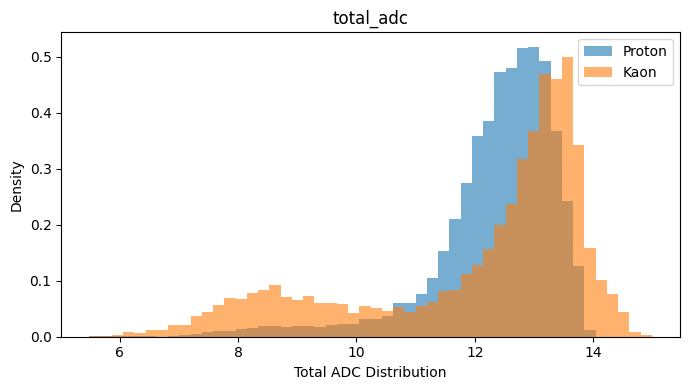

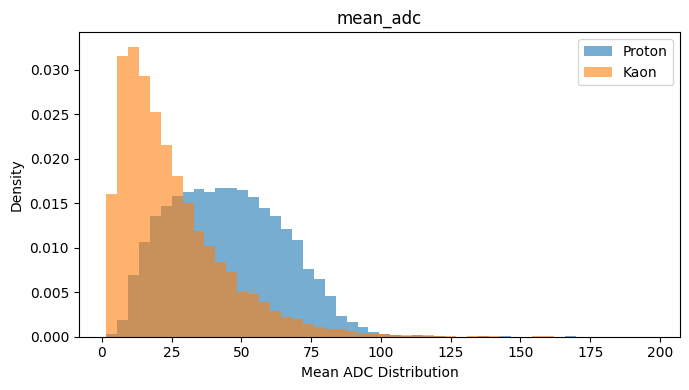

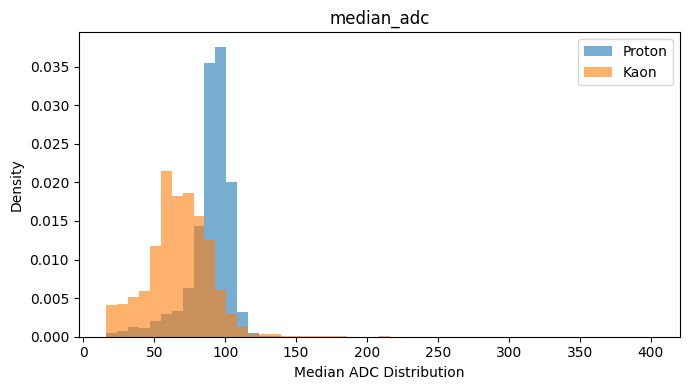

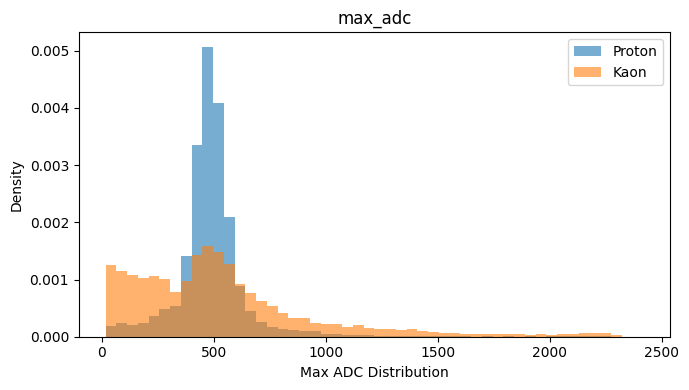

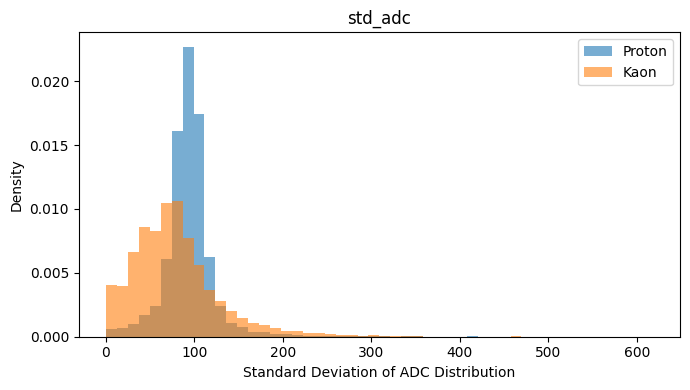

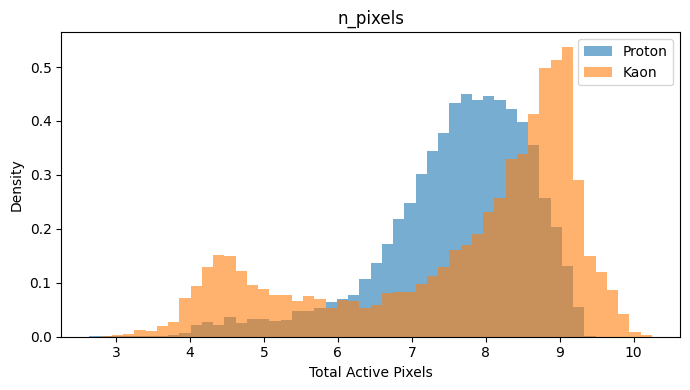

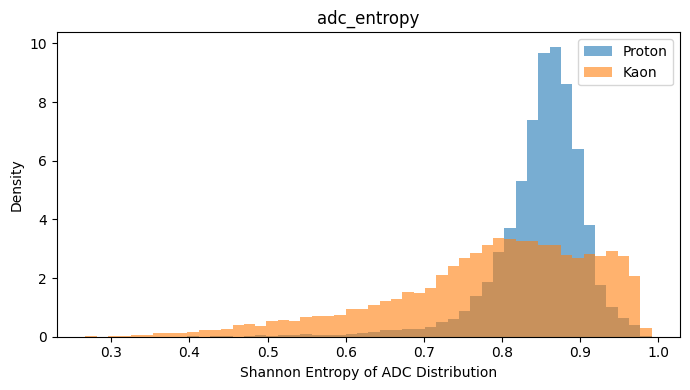

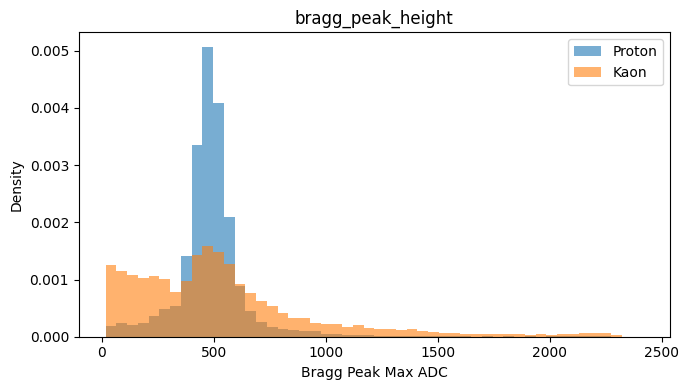

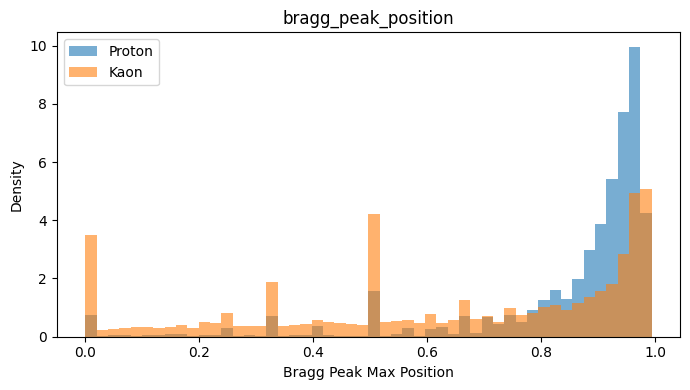

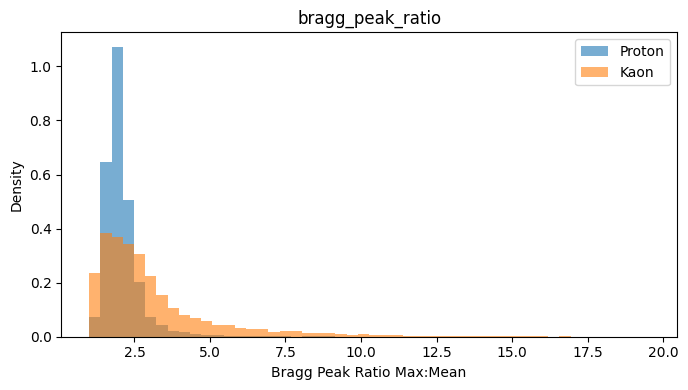

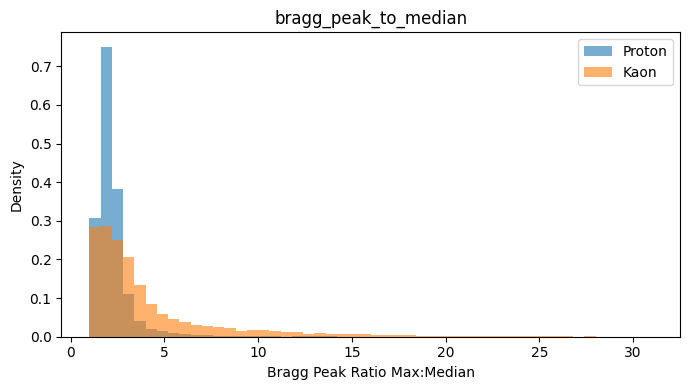

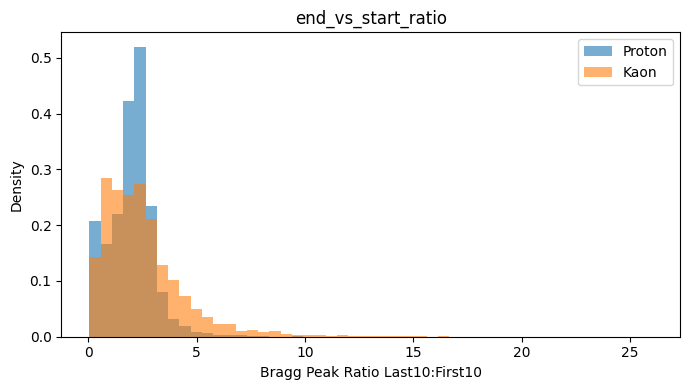

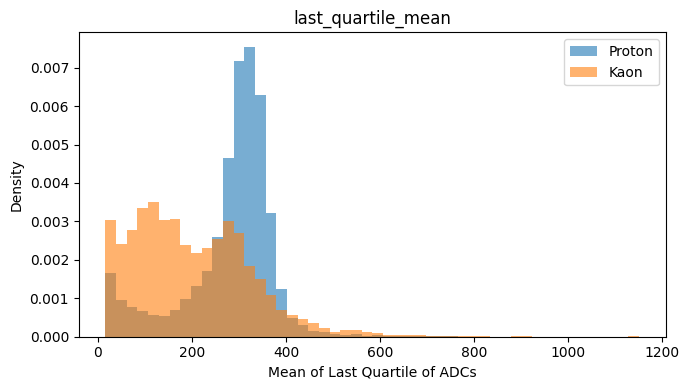

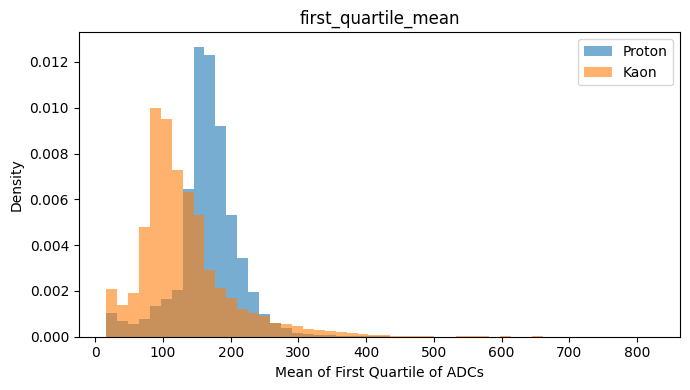

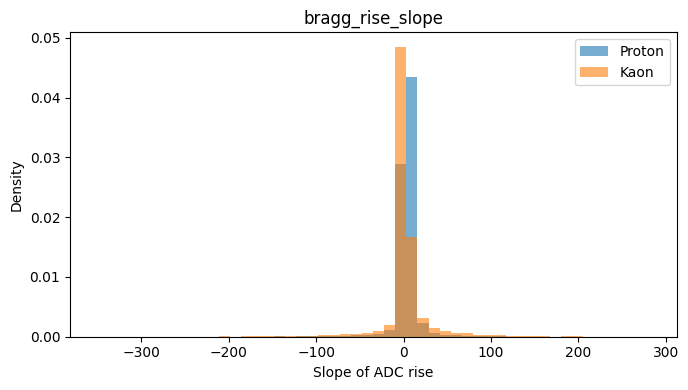

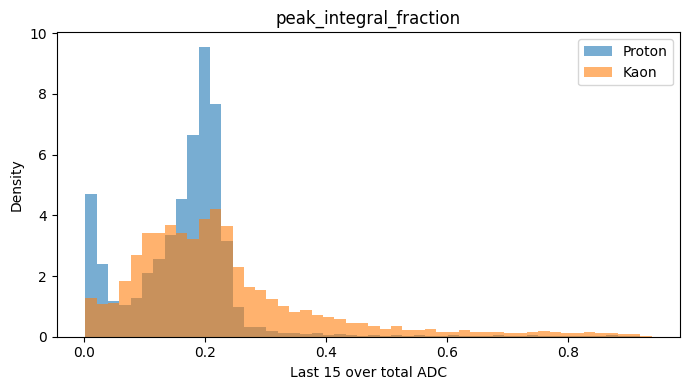

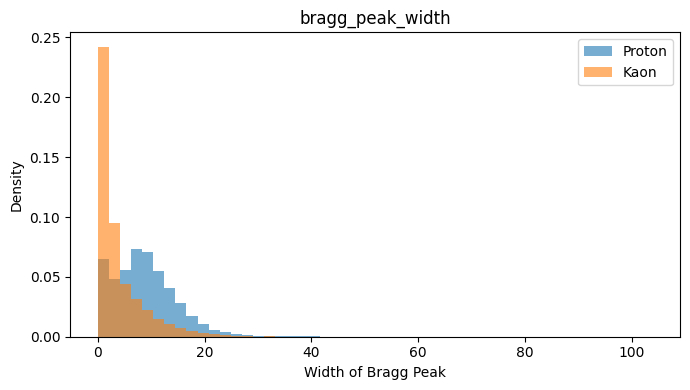

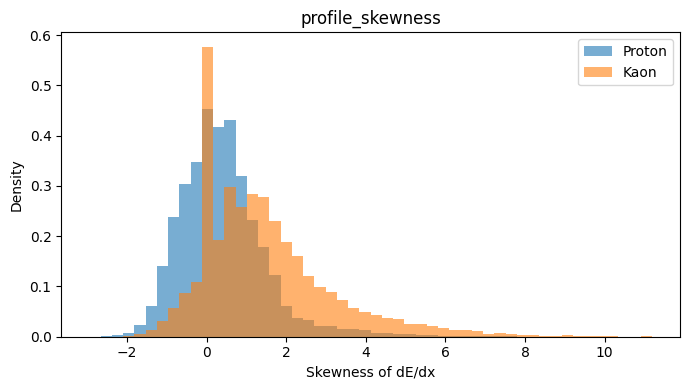

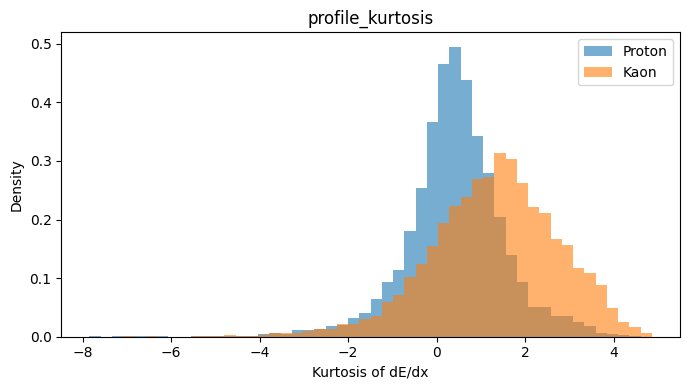

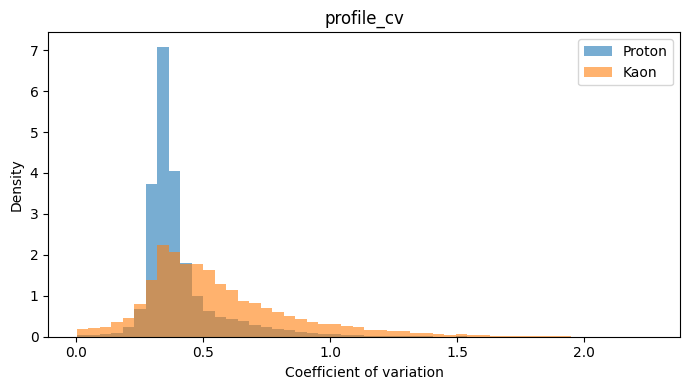

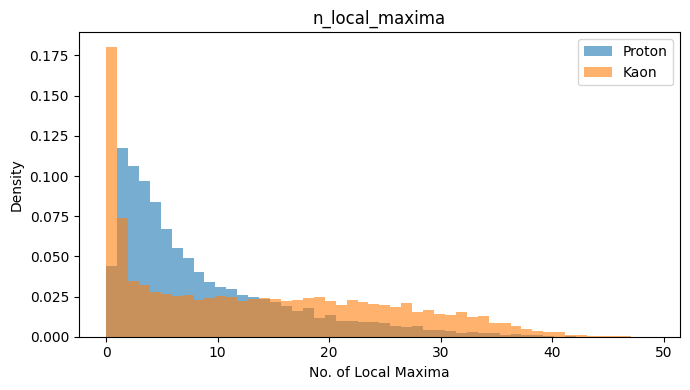

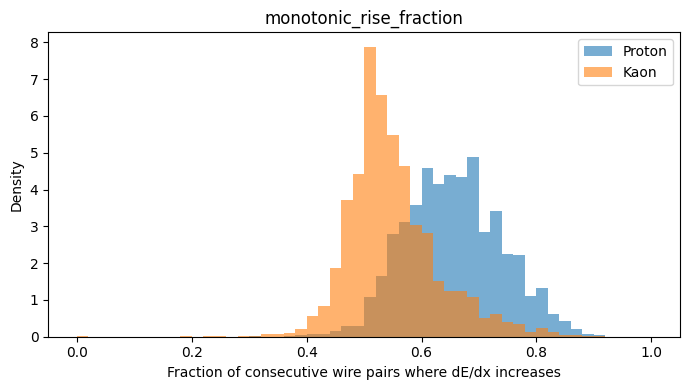

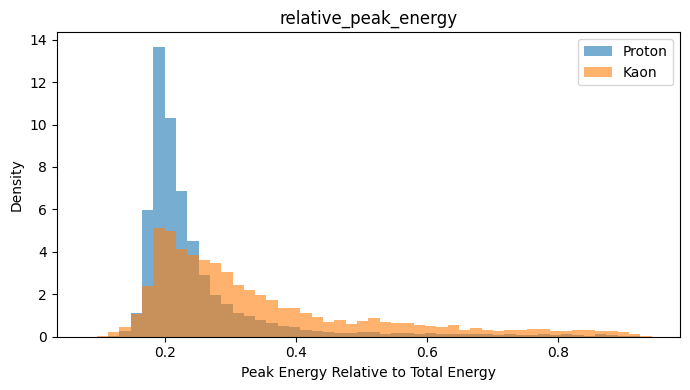

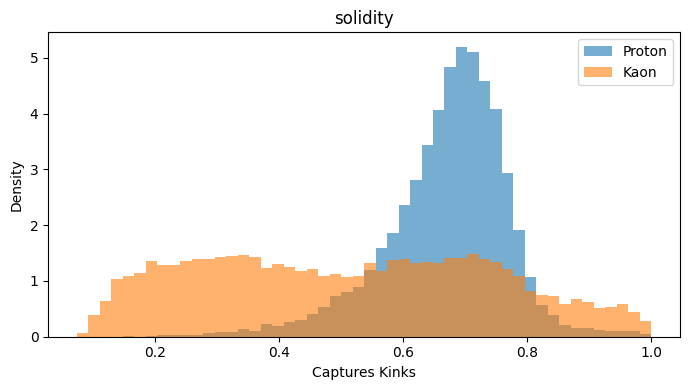

In [66]:
plot_feature(col, 'total_adc', bins=50, xlabel='Total ADC Distribution')
plot_feature(col, 'mean_adc', bins=50, xlabel='Mean ADC Distribution')
plot_feature(col, 'median_adc', bins=50, xlabel='Median ADC Distribution')
plot_feature(col, 'max_adc', bins=50, xlabel='Max ADC Distribution')
plot_feature(col, 'std_adc', bins=50, xlabel='Standard Deviation of ADC Distribution')
plot_feature(col, 'n_pixels', bins=50, xlabel='Total Active Pixels')
plot_feature(col, 'adc_entropy', bins=50, xlabel='Shannon Entropy of ADC Distribution')
plot_feature(col, 'bragg_peak_height', bins=50, xlabel='Bragg Peak Max ADC')
plot_feature(col, 'bragg_peak_position', bins=50, xlabel='Bragg Peak Max Position')
plot_feature(col, 'bragg_peak_ratio', bins=50, xlabel='Bragg Peak Ratio Max:Mean')
plot_feature(col, 'bragg_peak_to_median', bins=50, xlabel='Bragg Peak Ratio Max:Median')
plot_feature(col, 'end_vs_start_ratio', bins=50, xlabel='Bragg Peak Ratio Last10:First10')
plot_feature(col, 'last_quartile_mean', bins=50, xlabel='Mean of Last Quartile of ADCs')
plot_feature(col, 'first_quartile_mean', bins=50, xlabel='Mean of First Quartile of ADCs')
plot_feature(col, 'bragg_rise_slope', bins=50, xlabel='Slope of ADC rise')
plot_feature(col, 'peak_integral_fraction', bins=50, xlabel='Last 15 over total ADC')
plot_feature(col, 'bragg_peak_width', bins=50, xlabel='Width of Bragg Peak')
plot_feature(col, 'profile_skewness', bins=50, xlabel='Skewness of dE/dx')
plot_feature(col, 'profile_kurtosis', bins=50, xlabel='Kurtosis of dE/dx')
plot_feature(col, 'profile_cv', bins=50, xlabel='Coefficient of variation')
plot_feature(col, 'n_local_maxima', bins=50, xlabel='No. of Local Maxima')
plot_feature(col, 'monotonic_rise_fraction', bins=50, xlabel='Fraction of consecutive wire pairs where dE/dx increases')
plot_feature(col, 'relative_peak_energy', bins=50, xlabel='Peak Energy Relative to Total Energy')
plot_feature(col, 'solidity', bins=50, xlabel='Captures Kinks')